# Setup

In [1]:
lapply(c('viridis', 'ggthemes', 'skimr'),
       function(pkg_name) { if(! pkg_name %in% installed.packages()) { install.packages(pkg_name)} } )

library(viridis)    # A nice color scheme for plots.
library(ggthemes)   # Common themes to change the look and feel of plots.
library(scales)     # Graphical scales map data to aesthetics in plots.
library(skimr)      # Better summaries of data.
library(lubridate)  # Date library from the tidyverse.
library(tidyverse)  # Data wrangling packages.
library(bigrquery)  # Data extraction from Google BigQuery
library(data.table )

# Load required libraries
library(dplyr)
library(tidyr)
library(purrr)
library(broom)


install.packages("pROC")
library(pROC)

install.packages("ggpubr")
library(ggpubr)

install.packages("ggnewscale")
library(ggnewscale)

## Plot setup.
theme_set(theme_bw(base_size = 14)) # Default theme for plots.

#' Returns a data frame with a y position and a label, for use annotating ggplot boxplots.
#'
#' @param d A data frame.
#' @return A data frame with column y as max and column label as length.
get_boxplot_fun_data <- function(df) {
  return(data.frame(y = max(df), label = stringr::str_c('N = ', length(df))))
}

# Install and load metafor if needed
if (!requireNamespace("metafor", quietly = TRUE)) install.packages("metafor")
library(metafor)
library(dplyr)

# Get the bucket name
my_bucket <- Sys.getenv('WORKSPACE_BUCKET')

[[1]]
NULL

[[2]]
NULL

[[3]]
NULL

Loading required package: viridisLite


Attaching package: ‘scales’


The following object is masked from ‘package:viridis’:

    viridis_pal



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr   1.1.4     ✔ readr   2.1.5
✔ forcats 1.0.0     ✔ stringr 1.5.1
✔ ggplot2 3.5.2     ✔ tibble  3.2.1
✔ purrr   1.0.4     ✔ tidyr   1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ readr::col_factor() masks scales::col_factor()
✖ purrr::discard()    masks scales::discard()
✖ dplyr::filter()     masks stats::filter()
✖ dplyr::lag()        masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is

## Load and merge data

### Load data

In [2]:
# Imputed individual-level SDoH data
name_of_file_in_bucket <- 'imputed_individual_level_SDOH.csv'
system(paste0("gsutil cp ", my_bucket, "/data/", name_of_file_in_bucket, " ."), intern=T)
sdoh_data <- read_csv(name_of_file_in_bucket) |>
  rename(education = Education) #To differentiate from latent variable

# Case-control information
name_of_file_in_bucket <- 'Case_Control_df.csv'
system(paste0("gsutil cp ", my_bucket, "/data/", name_of_file_in_bucket, " ."), intern=T)
Case_Control_df  <- read_csv(name_of_file_in_bucket)

#Latent domains
name_of_file_in_bucket <- 'CFA_domain_SDOH_scores'
system(paste0("gsutil cp ", my_bucket, "/data/", name_of_file_in_bucket, " ."), intern=T)
CFA_domain_SDOH_scores  <- read_csv(name_of_file_in_bucket)

#Area data
name_of_file_in_bucket <- 'SES_cohort.csv'
system(paste0("gsutil cp ", my_bucket, "/data/", name_of_file_in_bucket, " ."), intern=T)
zip_code_socioeconomic_df  <- read_csv(name_of_file_in_bucket) 

character(0)

Rows: 54313 Columns: 37
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): SexGender
dbl (30): person_id, race_unknown, record_depth, visit_frequency, age, Educa...
lgl  (6): Black, Mid, Multiple, White, His, AANHPI

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


character(0)

Rows: 265954 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (10): person_id, Asthma, Afib, BreastC, CKD, CHD, HyperC, ProstateC, t2d...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


character(0)

Rows: 54286 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (7): person_id, SDOH, SCC, NBE, ES, HCAU, Education

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


character(0)

Rows: 125295 Columns: 63
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (6): SexGender, where_born, military, healthcare, disabled, sexual_ori...
dbl  (46): person_id, race_unknown, age_today, LGBTQIA, ehr_length, relative...
lgl   (8): AIAN, Asian, Black, Mid, Multiple, PI, White, His
date  (3): date_of_birth, min_date, max_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


### Make lists

In [3]:
diseases<-c("Asthma", "Afib", "BreastC", "CKD", "CHD", "HyperC", "ProstateC", "t2d", "t1d")

latent_domains<-c("SCC", "NBE", "ES", "HCAU", "Education")
SCC<-c("Social.Support", "Loneliness", "Social.Cohesion", "Everyday.Discrimination", "Stress", "Spiritual.Experiences")
NBE<-c("Crime", "Physical.Disorder", "Social.Disorder", "Walkability")
ES<-c("Own.Home","Housing.Quality", "Housing.Instability", "Food.Insecurity", "Percent.Poverty.Threshold")
HCAU<-c("Health.Literacy", "Medical.Discrimination", "Health.Coverage", "Healthcare.Utilization",
        "Delayed.Care", "Can.t.afford.care", "Worried.Pay", "Respect")


all_individual<-c(SCC, NBE, ES, HCAU, "Education")
SES <- c("Percent.Poverty.Threshold", "education")

SIRE <- c( "NHB", "HS")

area_level<-c("no_high_school_education", "lower_median_income", "no_health_insurance",  "vacant_housing", "deprivation_index")

all_terms_of_interest <- c(latent_domains, all_individual, area_level)

### Merge data

In [4]:
merged_data0<-merge(sdoh_data, Case_Control_df, on="person_id", how="left")

merged_data1<-merge(merged_data0, CFA_domain_SDOH_scores, on="person_id", how="left")

merged_data<-merge(merged_data1, zip_code_socioeconomic_df[,c(area_level, "person_id")], on="person_id", how="inner")


In [5]:
colnames(merged_data)

[1] "person_id"                 "Black"                    
 [3] "Mid"                       "Multiple"                 
 [5] "White"                     "His"                      
 [7] "race_unknown"              "SexGender"                
 [9] "record_depth"              "visit_frequency"          
[11] "age"                       "education"                
[13] "Own Home"                  "Health Literacy"          
[15] "Housing Quality"           "Housing Instability"      
[17] "Food Insecurity"           "Walkability"              
[19] "Loneliness"                "Crime"                    
[21] "Physical Disorder"         "Social Disorder"          
[23] "Everyday Discrimination"   "Medical Discrimination"   
[25] "Social Cohesion"           "Stress"                   
[27] "Social Support"            "Spiritual Experiences"    
[29] "Health Coverage"           "Healthcare Utilization"   
[31] "Delayed Care"              "Can't afford care"        
[33] "Worried Pay"               "Respect"                  
[35] "Percent Poverty Threshold" "age2"                     
[37] "AANHPI"                    "Asthma"                   
[39] "Afib"                      "BreastC"                  
[41] "CKD"                       "CHD"                      
[43] "HyperC"                    "ProstateC"                
[45] "t2d"                       "t1d"                      
[47] "SDOH"                      "SCC"                      
[49] "NBE"                       "ES"                       
[51] "HCAU"                      "Education"                
[53] "no_high_school_education"  "lower_median_income"      
[55] "no_health_insurance"       "vacant_housing"           
[57] "deprivation_index"

## Prepare Data

In [6]:
# Make one-hot encoded columns for each level of SexGender
merged_data <- merged_data %>%
  mutate(SexGender = as.factor(SexGender)) %>%
  mutate(dummy = 1) %>%
  pivot_wider(
    names_from = SexGender,
    values_from = dummy,
    values_fill = 0,
    names_prefix = ""
  )

In [7]:
colnames(merged_data) <- make.names(colnames(merged_data))

In [8]:
merged_data <- merged_data %>%
  mutate(
    SIRE = case_when(
      Black == 1 & His == 0 ~ "NHB",
      White == 1 & His == 0 ~ "NHW",
      His == 1 ~ "HS",
      TRUE ~ NA_character_
    )
  ) %>%
  filter(!is.na(SIRE)) %>%
  mutate(
    NHB = as.integer(SIRE == "NHB"),
    NHW = as.integer(SIRE == "NHW"),
    HS  = as.integer(SIRE == "HS")
  )

### Standardize binary variables, latent factors, area data

In [9]:
binary_cols <- c("Own.Home", "Housing.Quality", "Housing.Instability", "Health.Literacy",
                "Delayed.Care", "Can.t.afford.care", "Food.Insecurity")

# Standardize binary columns (z-score)
merged_data[binary_cols] <- lapply(merged_data[binary_cols], function(x) {
  (x - mean(x, na.rm = TRUE)) / sd(x, na.rm = TRUE)
})

merged_data[latent_domains] <- lapply(merged_data[latent_domains], function(x) {
  (x - mean(x, na.rm = TRUE)) / sd(x, na.rm = TRUE)
})

merged_data[area_level] <- lapply(merged_data[area_level], function(x) {
  (x - mean(x, na.rm = TRUE)) / sd(x, na.rm = TRUE)
})

                                    
flip_to_risk <-c("Social.Support", "Social.Cohesion", "Walkability", "Percent.Poverty.Threshold",
                "Own.Home", "Housing.Quality", "Respect", "Health.Literacy", "Health.Coverage")

merged_data[flip_to_risk] <- lapply(merged_data[flip_to_risk], function(x) -x)

                                    


# Logistic regressions

## Prepare functions

### Prepare models function

In [10]:
generate_model <- function(disease) {
  # Start with core predictors
  base_predictors <- c("age", "age2", "record_depth", "visit_frequency")
  
  # Conditional predictors base_predictorsd on disease
  if (disease %in% c("BreastC", "ProstateC")) {
    base_predictors <- c(base_predictors, "SGM")  # Include Cis_female and SGM for Breast Cancer
  } else if (disease %in% c("t1d", "CKD")) {
    base_predictors <- c(base_predictors, "Cis_male")  
  } else {
    base_predictors <- c(base_predictors, "Cis_male", "SGM")  # Include Cis_male and Cis_female for other diseases
  }

  
   list(Base= as.formula(paste(disease, "~", paste(base_predictors, collapse = " + "))), 
         `Base + SIRE` = as.formula(paste(disease, "~", paste(c(base_predictors, SIRE), collapse = " + "))), 
         `Base + SES` = as.formula(paste(disease, "~", paste(c(base_predictors, SES), collapse = " + "))), 
         `Base + Individual SDoH` = as.formula(paste(disease, "~", paste(c(base_predictors, all_individual), collapse = " + "))),
        `Base + SIRE + SES` = as.formula(paste(disease, "~", paste(c(base_predictors, SES, SIRE), collapse = " + "))), 
        `Base + SIRE + SDoH` = as.formula(paste(disease, "~", paste(c(base_predictors, all_individual, SIRE), collapse = " + ")))
)} 

### Logistic regression function

In [11]:
fit_model <- function(model, data, disease, model_name = "model") {
  
  if (disease %in% c("t1d", "CKD")) {
    data <- dplyr::filter(data, SGM == 0)
  }
  
  data_subset <- dplyr::filter(data, !is.na(.data[[disease]]))
  
  fit <- glm(model, data = data_subset, family = binomial(link = "logit"))
  
  probs <- predict(fit, type = "response")
  outcome <- data_subset[[disease]]
  
  # --- AUC + CI ---
  roc_obj <- pROC::roc(outcome, probs, quiet = TRUE)
  auc_val <- as.numeric(pROC::auc(roc_obj))
  auc_ci  <- pROC::ci.auc(roc_obj, method = "delong")
  
  meta_data <- tibble::tibble(
    Disease = disease,
    Model = model_name,
    N = nrow(data_subset),
    AUC = auc_val,
    AUC_CI_Lower = as.numeric(auc_ci[1]),
    AUC_CI_Upper = as.numeric(auc_ci[3])
  )
  
  actuals <- tibble::tibble(
    Disease = disease,
    Model = model_name,
    actual = outcome,
    prediction = probs
  )
  
  return(list(meta_data = meta_data,
              actuals = actuals))
}



### DeLong's Test of Significance for Model Performance Comparisons Function 

In [12]:
compare_models_auc <- function(df, disease_name) {

  models <- unique(df$Model)
  comparisons <- combn(models, 2, simplify = FALSE)

  purrr::map_dfr(comparisons, function(comp) {

    m1 <- comp[1]
    m2 <- comp[2]

    roc1 <- pROC::roc(
      df$actual[df$Model == m1],
      df$prediction[df$Model == m1],
      quiet = TRUE
    )

    roc2 <- pROC::roc(
      df$actual[df$Model == m2],
      df$prediction[df$Model == m2],
      quiet = TRUE
    )

    test <- pROC::roc.test(roc1, roc2,
                           method = "delong",
                           paired = TRUE)
   tibble(
      Disease = disease_name,
      Model1 = m1,
      Model2 = m2,
      AUC1 = as.numeric(pROC::auc(roc1)),
      AUC2 = as.numeric(pROC::auc(roc2)),
      AUC1_CI_Lower = as.numeric(pROC::ci.auc(roc1, method = "delong")[1]),
      AUC1_CI_Upper = as.numeric(pROC::ci.auc(roc1, method = "delong")[3]),
      AUC2_CI_Lower = as.numeric(pROC::ci.auc(roc2, method = "delong")[1]),
      AUC2_CI_Upper = as.numeric(pROC::ci.auc(roc2, method = "delong")[3]),
      Delta_AUC = as.numeric(pROC::auc(roc2)) - as.numeric(pROC::auc(roc1)),
      Delta_CI_low = test$conf.int[1],
      Delta_CI_high = test$conf.int[2],
      p_value = test$p.value
    )
      
  })
}


## Fit models

In [13]:
results_meta_data <- purrr::map_dfr(diseases, function(d) {

  formulas <- generate_model(d)

  purrr::imap_dfr(formulas, function(f, name) {

    fit_model(f, merged_data, d, model_name = name)$meta_data

  })

})

results_actuals <- purrr::map_dfr(diseases, function(d) {

  formulas <- generate_model(d)

  purrr::imap_dfr(formulas, function(f, name) {

    fit_model(f, merged_data, d, model_name = name)$actuals

  })

})

In [14]:
auc_comparisons <- purrr::map_dfr(unique(results_actuals$Disease), function(d) {

  df_d <- results_actuals %>% dplyr::filter(Disease == d)

  compare_models_auc(df_d, disease_name = d)

})

print(nrow(auc_comparisons))

auc_comparisons <- auc_comparisons %>%
  mutate(
    bonf_p = 0.05 / nrow(auc_comparisons),      # Bonferroni threshold
    p_value_bonf = p_value * nrow(auc_comparisons), # adjusted p-value
    p_value_bonf = ifelse(p_value_bonf > 1, 1, p_value_bonf), # cap at 1
    significant = p_value < bonf_p,              # TRUE/FALSE flag
    level = case_when(
      p_value_bonf < 0.05e-10 ~ "***",
      p_value_bonf < 0.05  ~ "**",
      p_value < 0.05  ~ "*",
      TRUE ~ ""
    )
  )

[1] 135


In [15]:
destination_filename <- 'logistic_regression_model_comparisons_individual_sdoh_cohort.csv'

write_excel_csv(auc_comparisons, destination_filename)
system(paste0("gsutil cp ./", destination_filename, " ", my_bucket, "/data/"), intern=T)

character(0)

# Plot 

## Setup

In [16]:
# Custom mapping for renaming diseases
disease_name_mapping <- c(
  "Asthma" = "Asthma\n(n=5560)",
  "Afib" = "Afib\n(n=4043)",
  "BreastC" = "Breast Cancer\n(n=2806)",
  "CKD" = "CKD\n(n=3800)",
  "CHD" = "CHD\n(n=6277)", 
  "HyperC" = "HCL\n(n=12893)",
  "ProstateC" = "Prostate Cancer\n(n=1915)",
  "t2d" = "T2D\n(n=8688)",
  "t1d" = "T1D\n(n=719)"
)




model_colors <- c(
  "Base"    = "grey",
  "Base + SIRE"    = "orange", 
  "Base + SES" = "skyblue",
  "Base + Individual SDoH"   = "darkblue"
)


# Map names
auc_plot_data <- results_meta_data %>% mutate(Disease = as.character(Disease), 
                                                    Disease = recode(Disease, 
                                                    !!!disease_name_mapping, 
                                                                     .default = Disease) )


auc_plot_data <- auc_plot_data %>%
  mutate(
    Model = factor(Model, levels = c("Base", "Base + SIRE", "Base + SES", "Base + Individual SDoH"))
  ) %>%
  filter(!is.na(Model))




In [17]:
# Define the adjacent pairs of interest
adjacent_pairs <- tibble::tibble(
  Model1 = c("Base", "Base + SIRE", "Base + SES"),
  Model2 = c("Base + SIRE", "Base + SES", "Base + Individual SDoH")
)

# Filter auc_comparisons to only those pairs
auc_comparisons_filtered <- auc_comparisons %>%
  mutate(
    Model1 = factor(Model1, levels = c("Base", "Base + SIRE", "Base + SES", "Base + Individual SDoH")),
    Model2 = factor(Model2, levels = c("Base", "Base + SIRE", "Base + SES", "Base + Individual SDoH"))
  ) %>%
  semi_join(adjacent_pairs, by = c("Model1", "Model2"))


In [18]:
# Number of repetitions per disease
n_per_disease <- 3  # for .8, 1, 1.2

# Number of diseases
n_diseases <- 9

# Total length
total <- n_per_disease * n_diseases

# Repeat sequence
# Base sequence
base_seq <- c(0.75, .95, 1.15)

# Generate x positions per disease
x_positions <- unlist(
  lapply(0:(n_diseases-1), function(i) base_seq + i)
)
    
y_positions <- c(.75, .75, .75, 
                     .75, .75, .75, 
                     .75, .75, .75, 
                     .83, .83, .83,
                     .9, .9, .9,
                     .86, .86, .86,
                     .75, .75, .75,
                     .78, .78, .78,
                     .8, .8, .8
                    ) 

# Assign in mutate
bracket_data <- auc_comparisons_filtered %>%
  mutate(
    Model1  = factor(Model1, levels = c("Base", "Base + SIRE", "Base + SES", "Base + Individual SDoH")),
    Model2  = factor(Model2, levels = c("Base", "Base + SIRE", "Base + SES", "Base + Individual SDoH"))
  ) %>%
  # sort by Disease so brackets are in order
  arrange(Disease, Model1, Model2) %>%
  mutate(
    xstart = x_positions,
    xend   = x_positions + 0.1,
    ypos   = y_positions
  ) %>%
  select(Disease, xstart, xend, ypos, Model1, Model2, p_value, Delta_AUC, level)


Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”
Warning message in geom_bracket(data = bracket_data, aes(xmin = xstart, xmax = xend, :
“Ignoring unknown parameters: `text.size`”


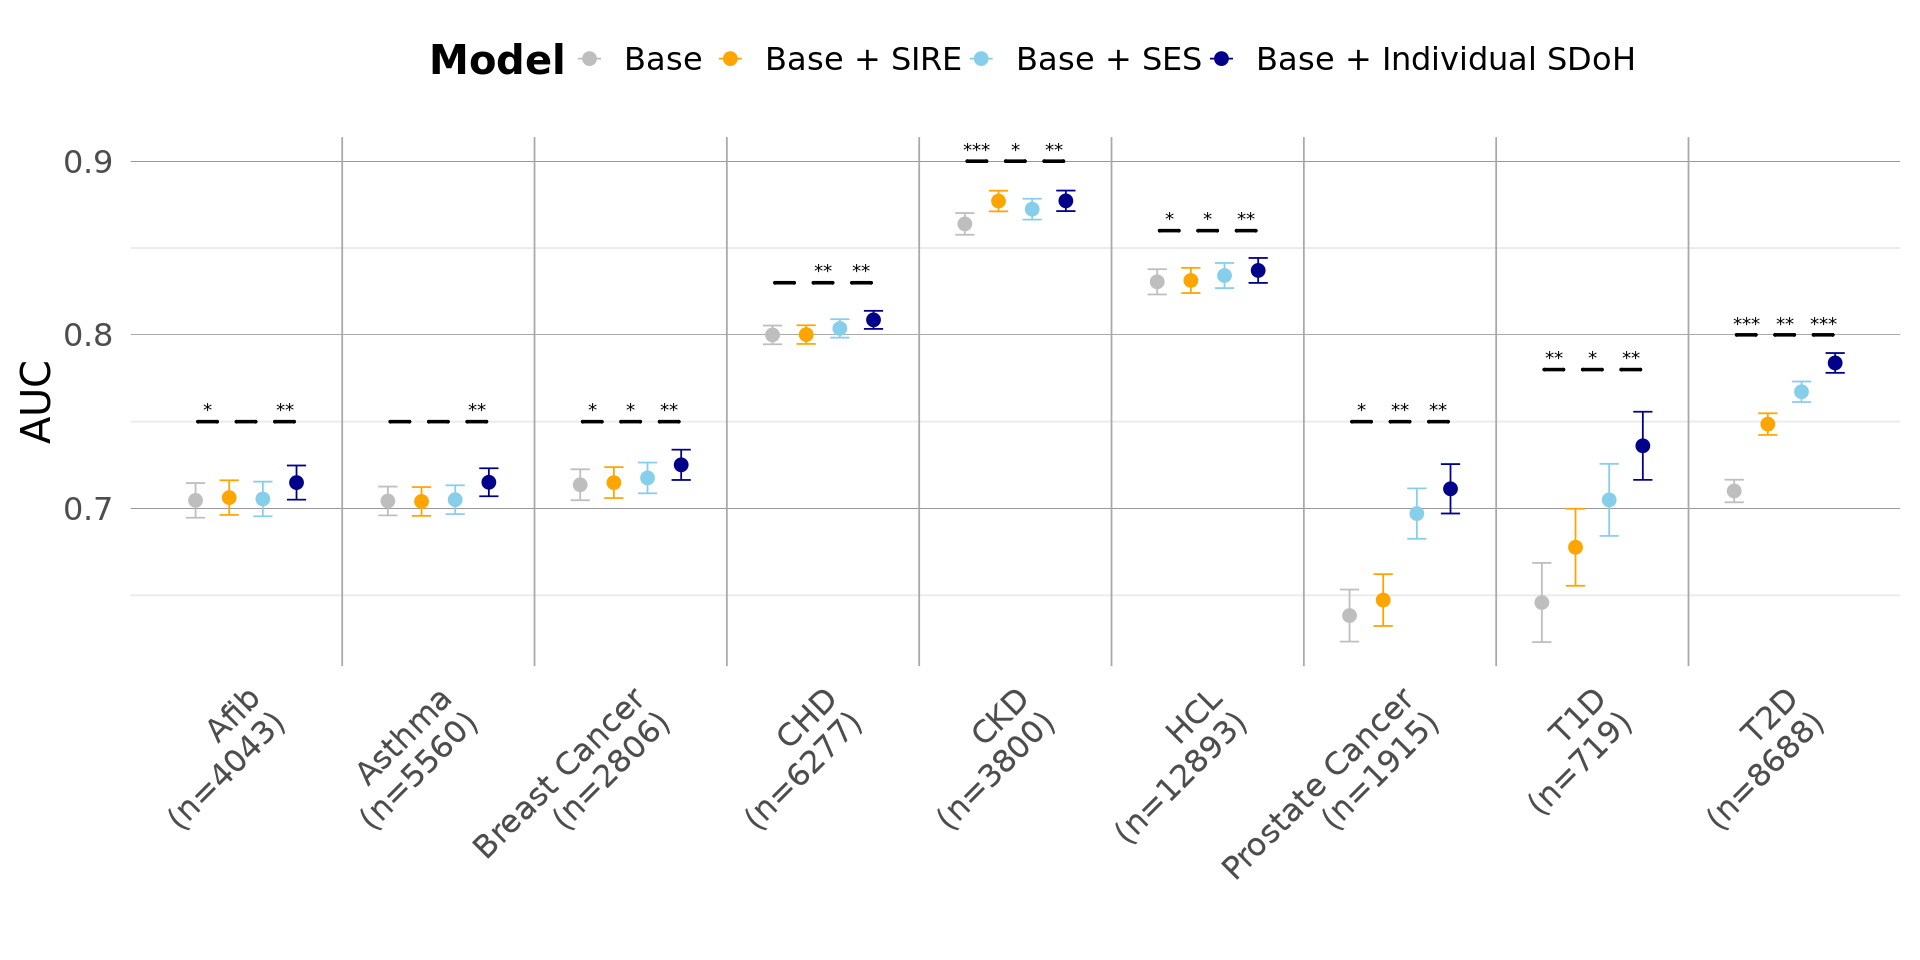

In [19]:
options(repr.plot.width = 16, repr.plot.height = 8)

ggplot(auc_plot_data, aes(x = Disease, y = AUC, color = Model)) +
  geom_point(position = position_dodge(width = 0.7), size = 3.5) +
  geom_errorbar(aes(ymin = AUC_CI_Lower, ymax = AUC_CI_Upper),
                position = position_dodge(width = 0.7), width = 0.4) +
  labs(x = "", y = "AUC") +
  theme_minimal(base_size = 24) +
  theme(
    legend.position = "top",
    axis.text.x = element_text(angle = 45, hjust = 1),
    strip.text = element_text(size = 12, face = "bold"),
    legend.title = element_text(face = "bold", hjust=.5),
    panel.grid.major.x = element_blank(),
    panel.grid.major.y = element_line(size = 0.1, color = "black")
  ) +
  scale_color_manual(values = model_colors, name = "Model") +
  geom_vline(xintercept = seq(1.5,
                              length(unique(auc_plot_data$Disease)) - 0.5,
                              1), color = "darkgrey") +
  # add comparisons
  geom_bracket(
    data = bracket_data,
    aes(xmin = xstart, xmax = xend, y.position = ypos,
        label = level),
    inherit.aes = FALSE,
    tip.length = 0.0,
    size = 1,
    text.size = 10,
    color = "black"
  )


In [20]:
adjacent_pairs <- tibble::tibble(
  Model1 = c("Base", "Base", "Base + SIRE"),
  Model2 = c("Base + SIRE", "Base + SES", "Base + SES")
)

# Filter auc_comparisons to only those pairs
auc_comparisons_filtered <- auc_comparisons %>%
  mutate(
    Model1 = factor(Model1, levels = c("Base", "Base + SIRE", "Base + SES")),
    Model2 = factor(Model2, levels = c("Base", "Base + SIRE", "Base + SES"))
  ) %>%
  semi_join(adjacent_pairs, by = c("Model1", "Model2"))

auc_plot_data2 <- auc_plot_data %>%
  mutate(
    Model = factor(Model, levels = c("Base", "Base + SIRE", "Base + SES"))
  ) %>%
  filter(!is.na(Model))

# Repeat sequence
# Base sequence
base_seq <- c(0.775, .775, 1.075)

# Generate x positions per disease
x_positions <- unlist(
  lapply(0:(n_diseases-1), function(i) base_seq + i)
)
    
y_positions <- c(.75, .765, .75, 
                     .75, .765, .75, 
                     .75, .765, .75, 
                     .83, .845, .83, 
                     .9, .915, .9, 
                     .86, .875, .86, 
                     .75, .765, .75, 
                     .78, .795, .78,
                     .8, .815, .8
                    ) 

# Assign in mutate
bracket_data <- auc_comparisons_filtered %>%
  mutate(
    Model1 = factor(Model1, levels = c("Base","Base + SIRE","Base + SES")),
    Model2 = factor(Model2, levels = c("Base","Base + SIRE","Base + SES")),
    span = as.numeric(Model2) - as.numeric(Model1)
  ) %>%
  arrange(Disease, Model1, Model2) %>%
  mutate(
    xstart = x_positions,
    xend   = x_positions + span * .2,
    ypos   = y_positions
  )
    

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


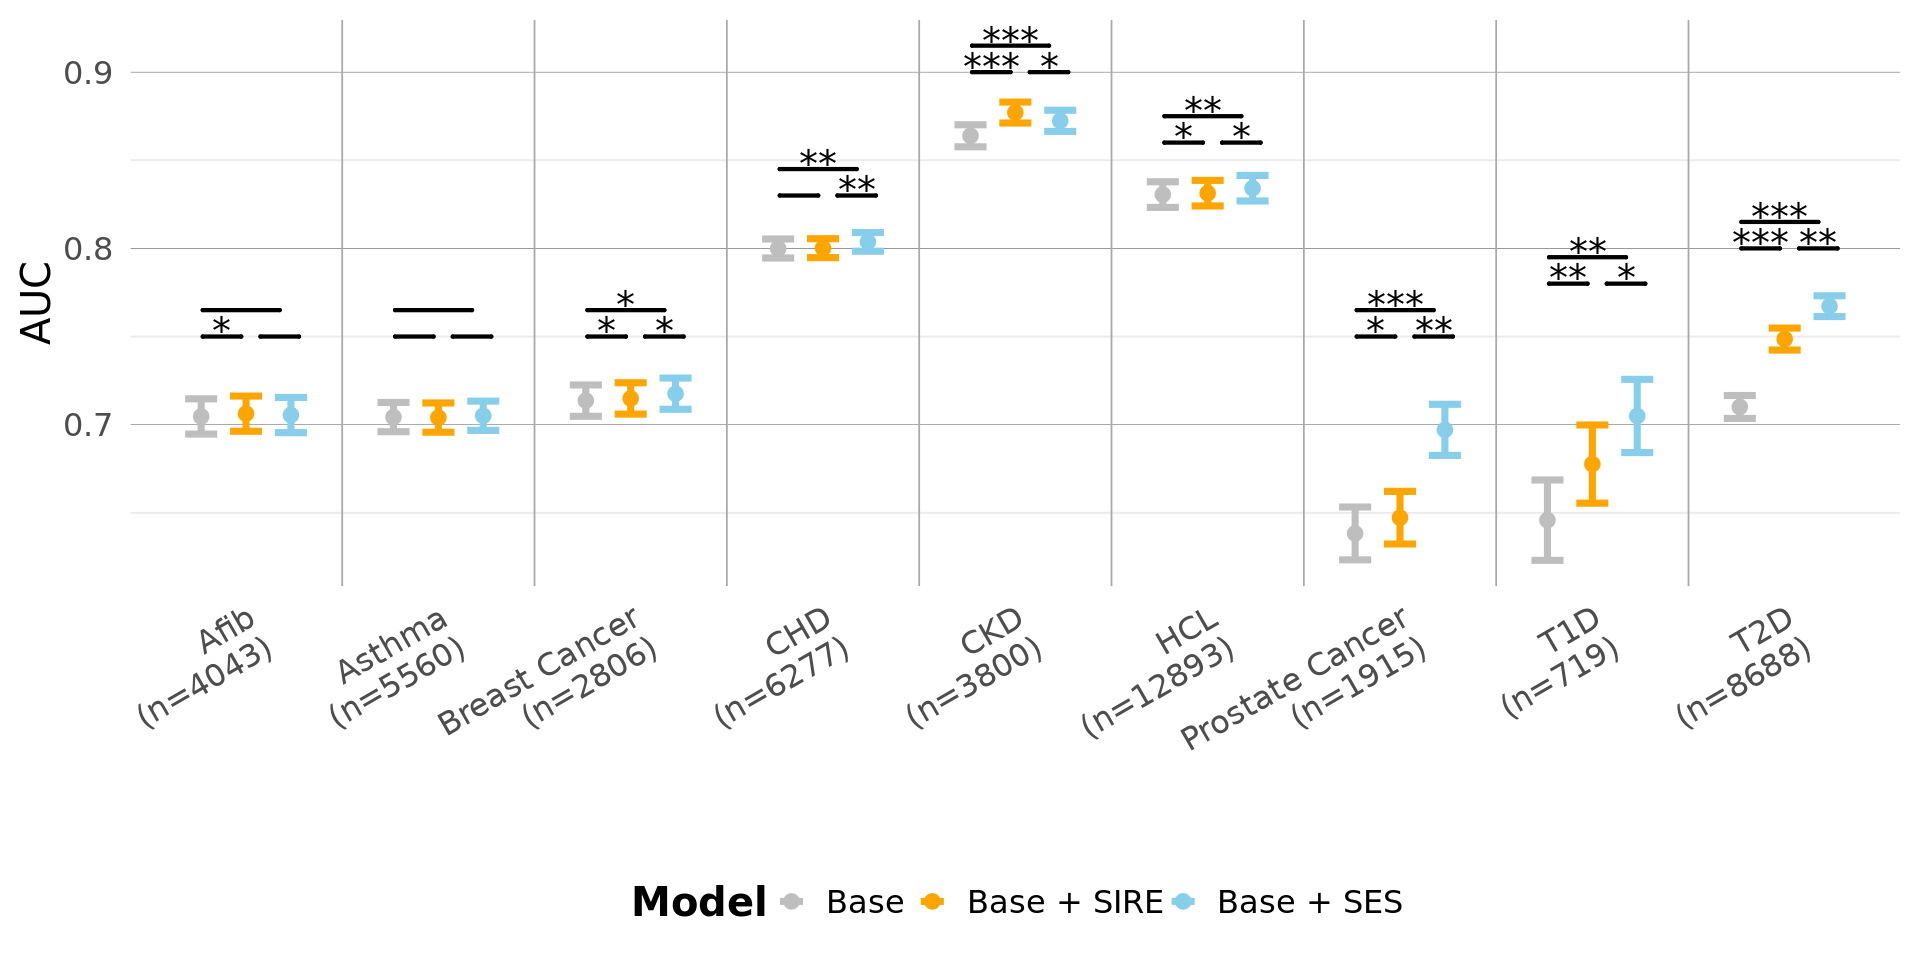

In [21]:
ggplot(auc_plot_data2, aes(x = Disease, y = AUC, color = Model)) +
  geom_point(position = position_dodge(width = 0.7), size = 4) +
  geom_errorbar(aes(ymin = AUC_CI_Lower, ymax = AUC_CI_Upper),
                position = position_dodge(width = 0.7), width = 0.5, size = 2) +
  labs(x = "", y = "AUC") +
  theme_minimal(base_size = 24) +
  theme(
    legend.position = "bottom",
    axis.text.x = element_text(angle = 30, hjust = 1),
    strip.text = element_text(size = 12, face = "bold"),
    legend.title = element_text(face = "bold", hjust=.5),
    panel.grid.major.x = element_blank(),
    panel.grid.major.y = element_line(size = 0.1, color = "black")
  ) +
  scale_color_manual(values = model_colors, name = "Model") +
  geom_vline(xintercept = seq(1.5,
                              length(unique(auc_plot_data$Disease)) - 0.5,
                              1), color = "darkgrey") +
  # add comparisons
  geom_bracket(
    data = bracket_data,
    aes(xmin = xstart, xmax = xend, y.position = ypos,
        label = level),
    inherit.aes = FALSE,
    tip.length = 0.0,
    size = 1.2,
    label.size = 8,
      vjust = .5,
    color = "black"
  )

## Compare percent improvement

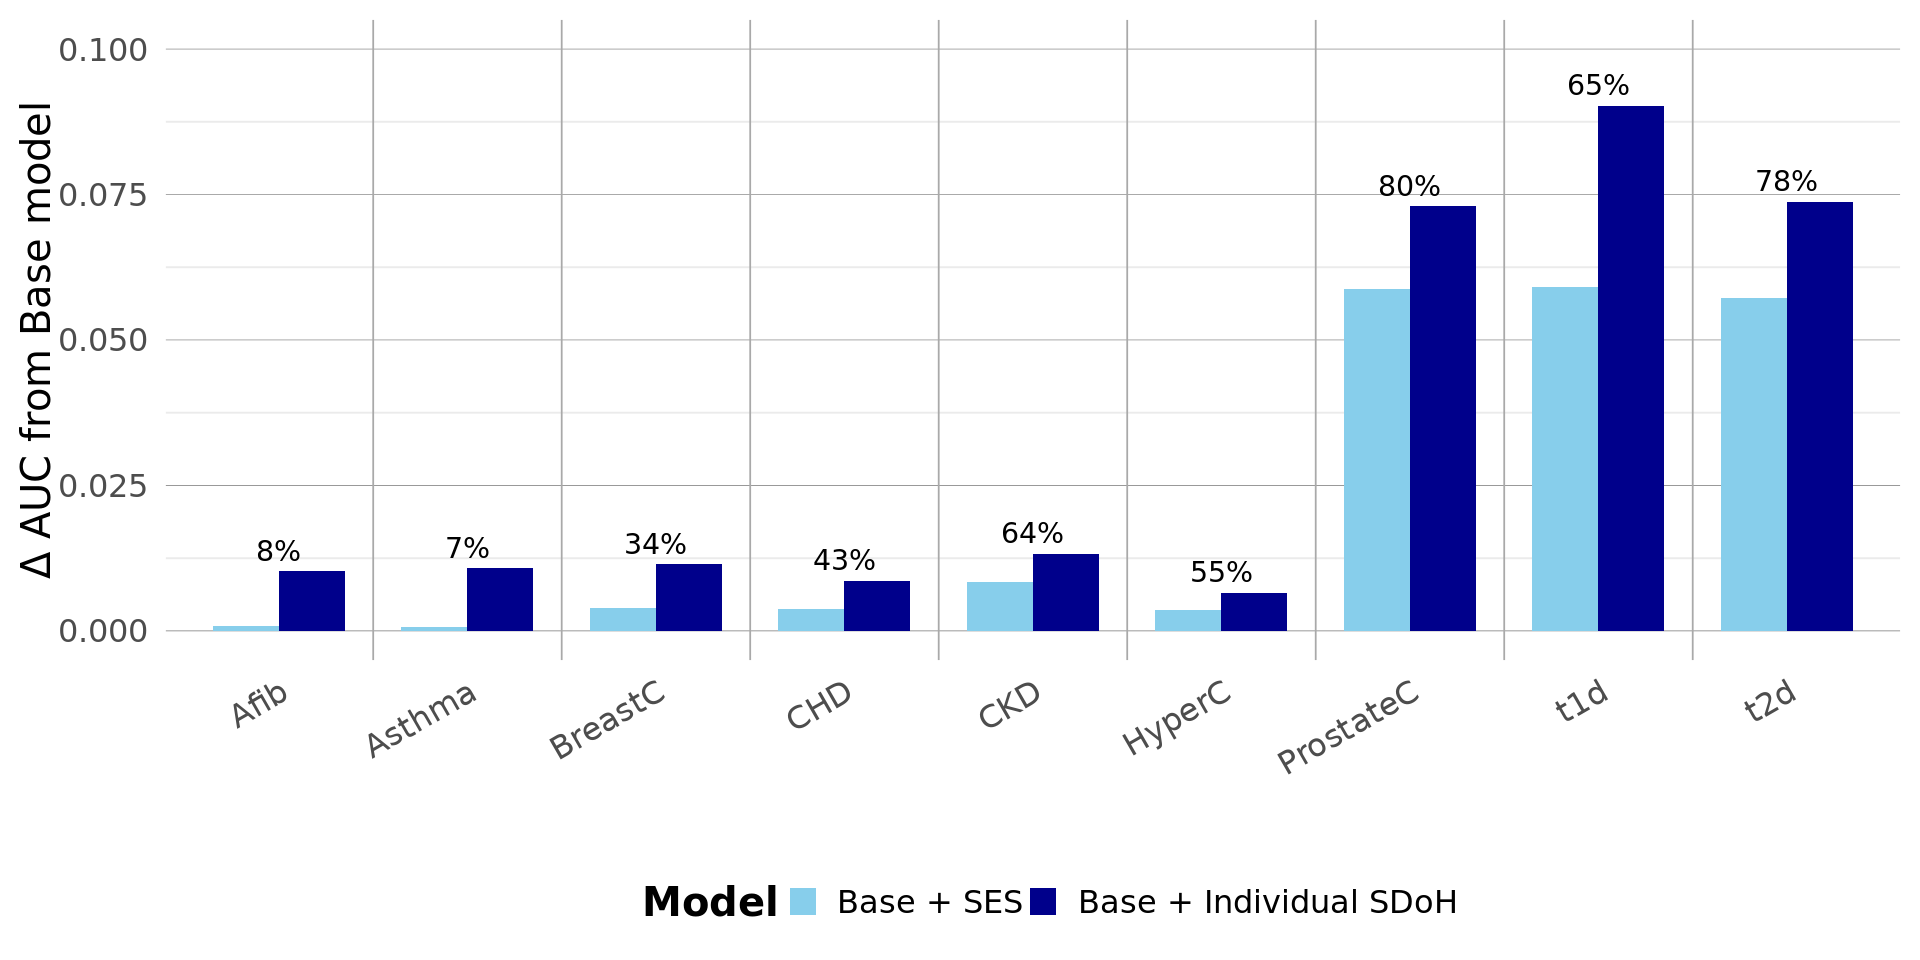

In [22]:
comp_of_interest <- auc_comparisons |> filter(Model2 %in% c( "Base + SES", "Base + Individual SDoH")
                                              & Model1 == "Base")

prop_df <- comp_of_interest |>
  select(Disease, Model2, Delta_AUC) |>
  pivot_wider(names_from = Model2, values_from = Delta_AUC) |>
  mutate(prop_captured = `Base + SES` / `Base + Individual SDoH`)

plot_df <- comp_of_interest |>
  left_join(prop_df |> select(Disease, prop_captured), by = "Disease") |>
 mutate(Model2 = factor(Model2, levels = c("Base + SES", "Base + Individual SDoH")))


ggplot(plot_df, aes(x = Disease, y = Delta_AUC, fill = Model2)) +
  geom_bar(stat = "identity", position = "dodge", width = 0.7) +
  geom_text(
    data = subset(plot_df, Model2 == "Base + Individual SDoH"),
    aes(label = scales::percent(prop_captured, accuracy = 1)),
    position = position_dodge(width = 0.7),
    vjust = -0.5,
    size = 6
  ) +
  labs(x = "", y = "Δ AUC from Base model") +
  theme_minimal(base_size = 24) +
  scale_y_continuous(limits = c(0, 0.1)) +
  theme(
    legend.position = "bottom",
    axis.text.x = element_text(angle = 30, hjust = 1),
    strip.text = element_text(size = 12, face = "bold"),
    legend.title = element_text(face = "bold", hjust = .5),
    panel.grid.major.x = element_blank(),
    panel.grid.major.y = element_line(linewidth = 0.1, color = "black")
  ) +
  scale_fill_manual(values = model_colors, name = "Model") +
  geom_vline(
    xintercept = seq(1.5, length(unique(comp_of_interest$Disease)) - 0.5, 1),
    color = "darkgrey"
  )

# Check OR of SIRE

In [23]:
fit_model_OR <- function(model, data, disease, model_name = "model") {
  
  # Filter by disease-specific sex/gender rules
  if (disease %in% c("t1d", "CKD")) {
    data <- dplyr::filter(data, SGM == 0)
  }
  
  # Remove missing outcomes
  data_subset <- dplyr::filter(data, !is.na(.data[[disease]]))
  
  # Fit logistic regression
  fit <- glm(model, data = data_subset, family = binomial(link = "logit"))
  
  # Extract coefficients
  coefs <- summary(fit)$coefficients
  
  # Convert to OR and 95% CI
  OR_df <- tibble::tibble(
    Disease      = disease,
    Model        = model_name,
    term         = rownames(coefs),
    estimate     = coefs[, "Estimate"],
    std_error    = coefs[, "Std. Error"],
    z_value      = coefs[, "z value"],
    p_value      = coefs[, "Pr(>|z|)"],
    OR           = exp(coefs[, "Estimate"]),
    OR_lower     = exp(coefs[, "Estimate"] - 1.96 * coefs[, "Std. Error"]),
    OR_upper     = exp(coefs[, "Estimate"] + 1.96 * coefs[, "Std. Error"])
  )
  
  
  return(OR_df)
}

In [24]:
results_OR_data <- purrr::map_dfr(diseases, function(d) {

  formulas <- generate_model(d)

  purrr::imap_dfr(formulas, function(f, name) {

    fit_model_OR(f, merged_data, d, model_name = name)

  })

})

In [25]:
results_OR_data_SIRE <- results_OR_data[results_OR_data$term %in% SIRE, ]

destination_filename <- 'logistic_regression_model_SIRE_OR_individual_sdoh_cohort.csv'

write_excel_csv(results_OR_data_SIRE, destination_filename)
system(paste0("gsutil cp ./", destination_filename, " ", my_bucket, "/data/"), intern=T)

character(0)

In [26]:
results_OR_data_SIRE <- results_OR_data_SIRE[results_OR_data_SIRE$Disease %in% c("t2d", "t1d", "CKD"), ]

results_OR_data_SIRE <- results_OR_data_SIRE %>% mutate(Disease = as.character(Disease), 
                                                    Disease = recode(Disease, 
                                                    !!!disease_name_mapping, 
                                                                     .default = Disease) )

# Reorder Disease factor so that it appears top-to-bottom
results_OR_data_SIRE <- results_OR_data_SIRE %>%
  mutate(
    Disease = factor(Disease, levels = unique(Disease)),
    Model   = factor(Model, levels = c("Base + SIRE", "Base + SIRE + SES", "Base + SIRE + SDoH")),
    Group   = factor(term, levels = c("NHB", "HS")) 
  ) %>%
  arrange(Disease, Model)

results_OR_data <- results_OR_data_SIRE

results_OR_data_NHB <- results_OR_data_SIRE[results_OR_data_SIRE$term == "NHB", ]
results_OR_data_HS <- results_OR_data_SIRE[results_OR_data_SIRE$term == "HS", ]


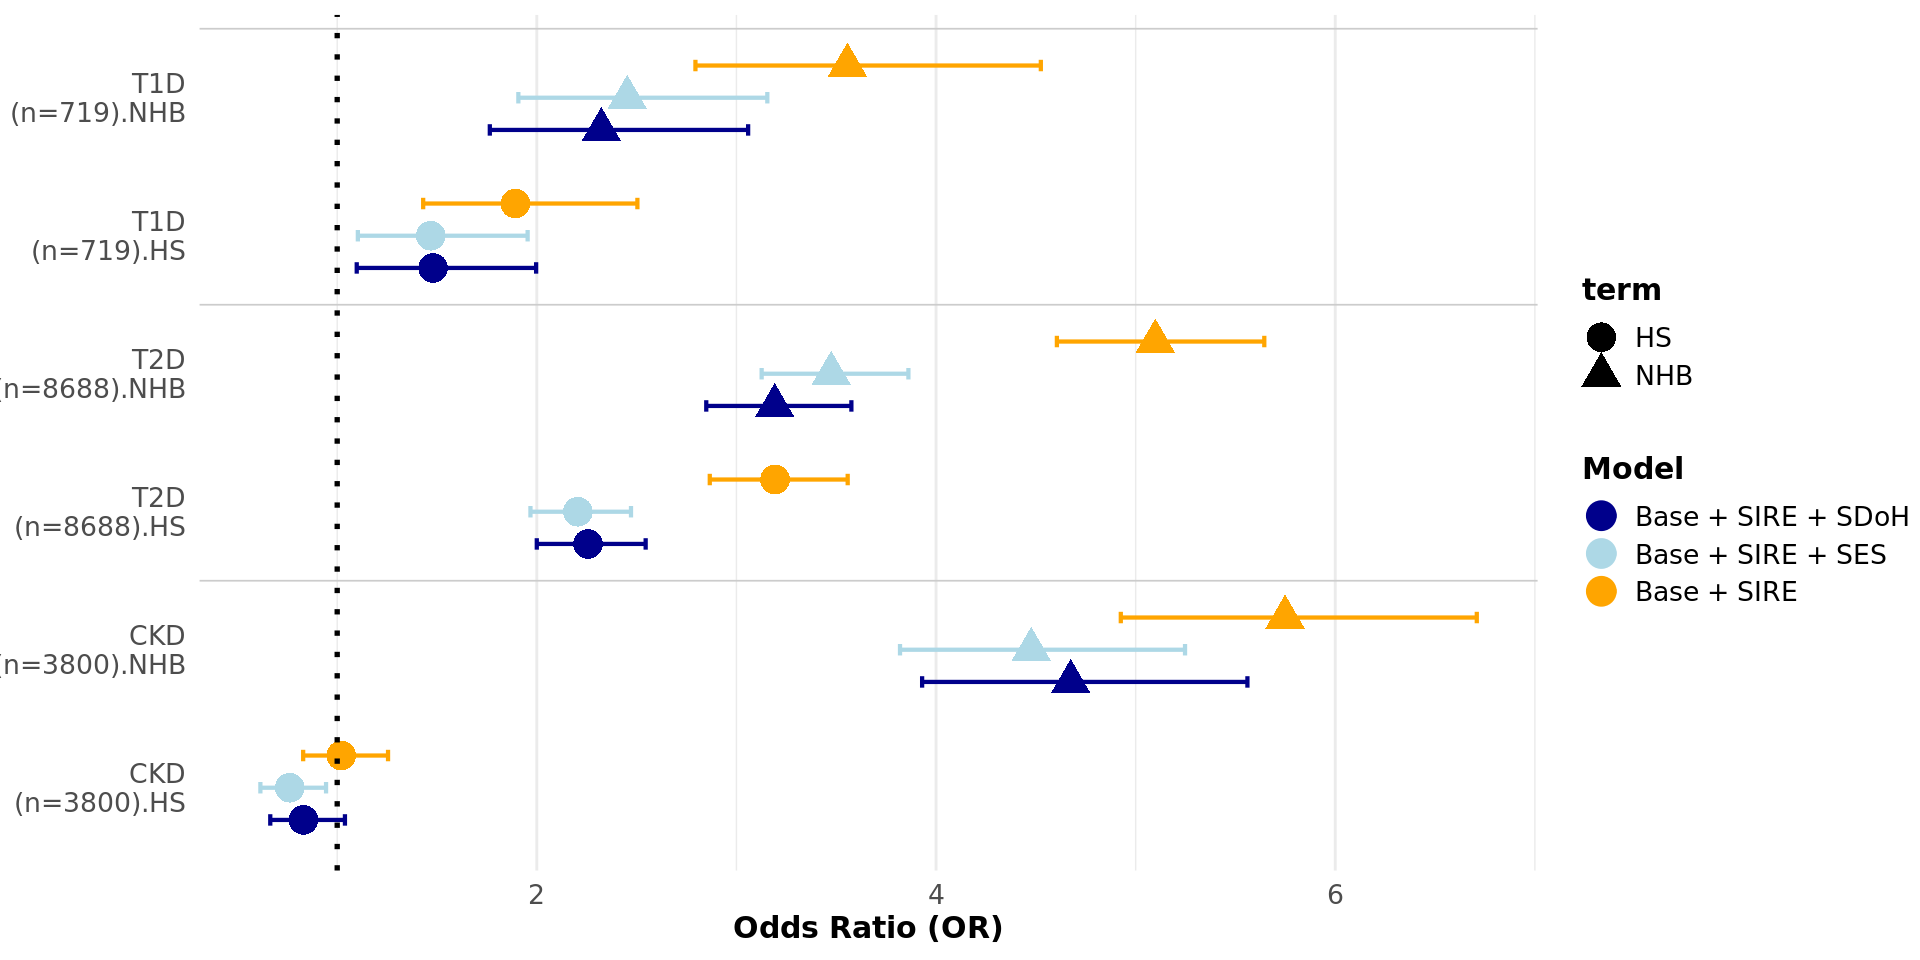

In [27]:

results_OR_data <- results_OR_data %>%
  mutate(Disease_term = interaction(Disease, term, lex.order = TRUE))

disease_breaks <- seq(2.5,
                      length(unique(results_OR_data$Disease_term)) + 2,
                      by = length(unique(results_OR_data$term)))

ggplot(results_OR_data, 
       aes(x = OR, y = Disease_term, color = fct_rev(Model), shape = term)) +
  geom_point(position = position_dodge(width = 0.7), 
             size = 8) +   # larger points
  geom_errorbarh(aes(xmin = OR_lower, xmax = OR_upper),
                 position = position_dodge(width = 0.7), 
                 height = 0.25,
                 linewidth = 1.2) +   # thicker error bars
 scale_color_manual(values = c("Base + SIRE" = "orange",
                                "Base + SIRE + SES" = "lightblue",
                                "Base + SIRE + SDoH" = "darkblue")) +
  labs(x = "Odds Ratio (OR)", y = NULL, color = "Model") +
  theme_minimal(base_size = 18) +   # increases most text
  theme(
    legend.position = "bottom",
    strip.text = element_text(face = "bold", size = 18),
    axis.text = element_text(size = 16),
    axis.title = element_text(size = 18, face = "bold"),
    legend.text = element_text(size = 16),
    legend.title = element_text(size = 18, face = "bold")) + 
  theme(
    legend.position = "right",
    panel.grid.major.y = element_blank()) +
  geom_hline(yintercept = disease_breaks, color = "grey80") + 
  geom_vline(xintercept = 1, 
             linetype = "dotted", 
             color = "black", 
             linewidth = 1.5)

# Percent Improvement in Individual SDoH Cohort

## Prepare Data

In [28]:
merged_data0<-merge(sdoh_data, Case_Control_df, on="person_id", how="left")

merged_data1<-merge(merged_data0, CFA_domain_SDOH_scores, on="person_id", how="left")

merged_data<-merge(merged_data1, zip_code_socioeconomic_df[,c(area_level, "person_id")], on="person_id", how="inner")

# Make one-hot encoded columns for each level of SexGender
merged_data <- merged_data %>%
  mutate(SexGender = as.factor(SexGender)) %>%
  mutate(dummy = 1) %>%
  pivot_wider(
    names_from = SexGender,
    values_from = dummy,
    values_fill = 0,
    names_prefix = ""
  )

colnames(merged_data) <- make.names(colnames(merged_data))

binary_cols <- c("Own.Home", "Housing.Quality", "Housing.Instability", "Health.Literacy",
                "Delayed.Care", "Can.t.afford.care", "Food.Insecurity")

# Standardize binary columns (z-score)
merged_data[binary_cols] <- lapply(merged_data[binary_cols], function(x) {
  (x - mean(x, na.rm = TRUE)) / sd(x, na.rm = TRUE)
})

merged_data[latent_domains] <- lapply(merged_data[latent_domains], function(x) {
  (x - mean(x, na.rm = TRUE)) / sd(x, na.rm = TRUE)
})

merged_data[area_level] <- lapply(merged_data[area_level], function(x) {
  (x - mean(x, na.rm = TRUE)) / sd(x, na.rm = TRUE)
})

                                    
flip_to_risk <-c("Social.Support", "Social.Cohesion", "Walkability", "Percent.Poverty.Threshold",
                "Own.Home", "Housing.Quality", "Respect", "Health.Literacy", "Health.Coverage")

merged_data[flip_to_risk] <- lapply(merged_data[flip_to_risk], function(x) -x)



## Run Regressions

In [29]:
generate_model <- function(disease) {
  # Start with core predictors
  base_predictors <- c("age", "age2", "record_depth", "visit_frequency")
  
  # Conditional predictors base_predictorsd on disease
  if (disease %in% c("BreastC", "ProstateC")) {
    base_predictors <- c(base_predictors, "SGM")  # Include Cis_female and SGM for Breast Cancer
  } else if (disease %in% c("t1d", "CKD")) {
    base_predictors <- c(base_predictors, "Cis_male")  
  } else {
    base_predictors <- c(base_predictors, "Cis_male", "SGM")  # Include Cis_male and Cis_female for other diseases
  }

  
   list(Base= as.formula(paste(disease, "~", paste(base_predictors, collapse = " + "))), 
         `Base + SES` = as.formula(paste(disease, "~", paste(c(base_predictors, SES), collapse = " + "))), 
         `Base + Individual SDoH` = as.formula(paste(disease, "~", paste(c(base_predictors, all_individual), collapse = " + ")))
)}

In [30]:
results_meta_data <- purrr::map_dfr(diseases, function(d) {

  formulas <- generate_model(d)

  purrr::imap_dfr(formulas, function(f, name) {

    fit_model(f, merged_data, d, model_name = name)$meta_data

  })

})

results_actuals <- purrr::map_dfr(diseases, function(d) {

  formulas <- generate_model(d)

  purrr::imap_dfr(formulas, function(f, name) {

    fit_model(f, merged_data, d, model_name = name)$actuals

  })

})

auc_comparisons <- purrr::map_dfr(unique(results_actuals$Disease), function(d) {

  df_d <- results_actuals %>% dplyr::filter(Disease == d)

  compare_models_auc(df_d, disease_name = d)

})


auc_comparisons <- auc_comparisons %>%
  mutate(
    bonf_p = 0.05 / nrow(auc_comparisons),      # Bonferroni threshold
    p_value_bonf = p_value * nrow(auc_comparisons), # adjusted p-value
    p_value_bonf = ifelse(p_value_bonf > 1, 1, p_value_bonf), # cap at 1
    significant = p_value < bonf_p,              # TRUE/FALSE flag
    level = case_when(
      p_value_bonf < 0.05e-10 ~ "***",
      p_value_bonf < 0.05  ~ "**",
      p_value < 0.05  ~ "*",
      TRUE ~ ""
    )
  )

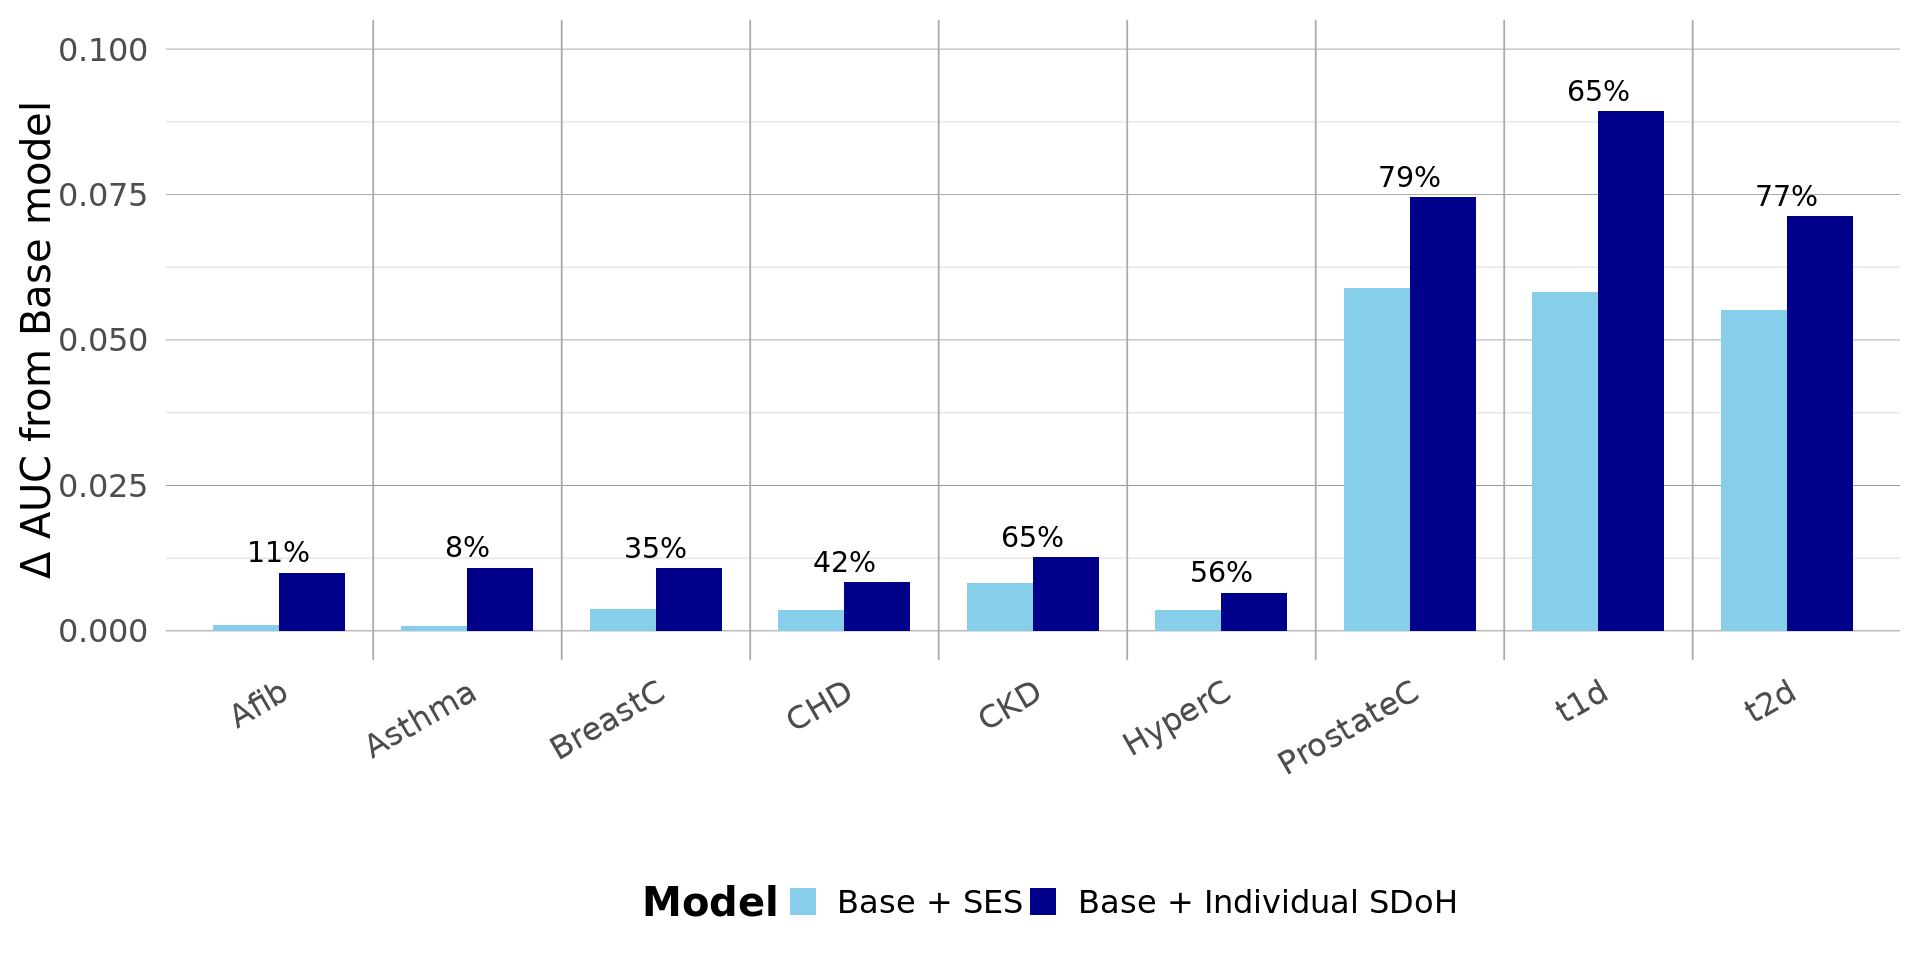

In [31]:
comp_of_interest <- auc_comparisons |> filter(Model2 %in% c( "Base + SES", "Base + Individual SDoH")
                                              & Model1 == "Base")

prop_df <- comp_of_interest |>
  select(Disease, Model2, Delta_AUC) |>
  pivot_wider(names_from = Model2, values_from = Delta_AUC) |>
  mutate(prop_captured = `Base + SES` / `Base + Individual SDoH`)

plot_df <- comp_of_interest |>
  left_join(prop_df |> select(Disease, prop_captured), by = "Disease") |>
 mutate(Model2 = factor(Model2, levels = c("Base + SES", "Base + Individual SDoH")))


ggplot(plot_df, aes(x = Disease, y = Delta_AUC, fill = Model2)) +
  geom_bar(stat = "identity", position = "dodge", width = 0.7) +
  geom_text(
    data = subset(plot_df, Model2 == "Base + Individual SDoH"),
    aes(label = scales::percent(prop_captured, accuracy = 1)),
    position = position_dodge(width = 0.7),
    vjust = -0.5,
    size = 6
  ) +
  labs(x = "", y = "Δ AUC from Base model") +
  theme_minimal(base_size = 24) +
  scale_y_continuous(limits = c(0, 0.1)) +
  theme(
    legend.position = "bottom",
    axis.text.x = element_text(angle = 30, hjust = 1),
    strip.text = element_text(size = 12, face = "bold"),
    legend.title = element_text(face = "bold", hjust = .5),
    panel.grid.major.x = element_blank(),
    panel.grid.major.y = element_line(linewidth = 0.1, color = "black")
  ) +
  scale_fill_manual(values = model_colors, name = "Model") +
  geom_vline(
    xintercept = seq(1.5, length(unique(comp_of_interest$Disease)) - 0.5, 1),
    color = "darkgrey"
  )

# Area SIRE Cohort

## Prepare data

In [82]:
merged_data<-merge(zip_code_socioeconomic_df, Case_Control_df, on="person_id", how="left")

# Make one-hot encoded columns for each level of SexGender
merged_data <- merged_data %>%
  mutate(SexGender = as.factor(SexGender)) %>%
  mutate(dummy = 1) %>%
  pivot_wider(
    names_from = SexGender,
    values_from = dummy,
    values_fill = 0,
    names_prefix = ""
  )                                                                      
                                    
merged_data <- merged_data %>%
  mutate(
    SIRE = case_when(
      Black == 1 & His == 0 ~ "NHB",
      White == 1 & His == 0 ~ "NHW",
      His == 1 ~ "HS",
      TRUE ~ NA_character_
    )
  ) %>%
  filter(!is.na(SIRE)) %>%
  mutate(
    NHB = as.integer(SIRE == "NHB"),
    NHW = as.integer(SIRE == "NHW"),
    HS  = as.integer(SIRE == "HS")
  )

disease_name_mapping <- c(
  "Asthma" = "Asthma\n(n=11592)",
  "Afib" = "Afib\n(n=7823)",
  "BreastC" = "Breast Cancer\n(n=5039)",
  "CKD" = "CKD\n(n=8802)",
  "CHD" = "CHD\n(n=14030)", 
  "HyperC" = "HCL\n(n=25199)",
  "ProstateC" = "Prostate Cancer\n(n=3397)",
  "t2d" = "T2D\n(n=19920)",
  "t1d" = "T1D\n(n=1225)"
)

## Check OR of SIRE

### Generate Models

In [83]:
SES <- c("per_poverty_threshold", "education")

generate_model <- function(disease) {
  # Start with core predictors
  base_predictors <- c("age", "age2", "record_depth", "visit_frequency")
  
  # Conditional predictors base_predictorsd on disease
  if (disease %in% c("BreastC", "ProstateC")) {
    base_predictors <- c(base_predictors, "SGM")  # Include Cis_female and SGM for Breast Cancer
  } else if (disease %in% c("t1d", "CKD")) {
    base_predictors <- c(base_predictors, "Cis_male")  
  } else {
    base_predictors <- c(base_predictors, "Cis_male", "SGM")  # Include Cis_male and Cis_female for other diseases
  }

  
   list(Base= as.formula(paste(disease, "~", paste(base_predictors, collapse = " + "))), 
        `Base + SIRE`= as.formula(paste(disease, "~", paste(c(base_predictors, SIRE), collapse = " + "))), 
         `Base + SIRE + SES`= as.formula(paste(disease, "~", paste(c(base_predictors, SIRE, SES), collapse = " + ")))
        )
}

In [84]:
results_OR_data <- purrr::map_dfr(diseases, function(d) {

  formulas <- generate_model(d)

  purrr::imap_dfr(formulas, function(f, name) {

    fit_model_OR(f, merged_data, d, model_name = name)

  })

})

results_OR_data_SIRE <- results_OR_data[results_OR_data$term %in% SIRE, ]

destination_filename <- 'logistic_regression_model_SIRE_OR_SES_cohort.csv'

write_excel_csv(results_OR_data_SIRE, destination_filename)
system(paste0("gsutil cp ./", destination_filename, " ", my_bucket, "/data/"), intern=T)

results_OR_data_SIRE <- results_OR_data_SIRE[results_OR_data_SIRE$Disease %in% c("t2d", "t1d", "CKD"), ]


results_OR_data_SIRE <- results_OR_data_SIRE %>% mutate(Disease = as.character(Disease), 
                                                    Disease = recode(Disease, 
                                                    !!!disease_name_mapping, 
                                                                     .default = Disease) )

character(0)

In [85]:
# Reorder Disease factor so that it appears top-to-bottom
results_OR_data_SIRE <- results_OR_data_SIRE %>%
  mutate(
    Disease = factor(Disease, levels = unique(Disease)),
    Model   = factor(Model, levels = c("Base + SIRE", "Base + SIRE + SES")),
    Group   = factor(term, levels = c("NHB", "HS")) 
  ) %>%
  arrange(Disease, Model)

results_OR_data <- results_OR_data_SIRE

results_OR_data_NHB <- results_OR_data_SIRE[results_OR_data_SIRE$term == "NHB", ]
results_OR_data_HS <- results_OR_data_SIRE[results_OR_data_SIRE$term == "HS", ]



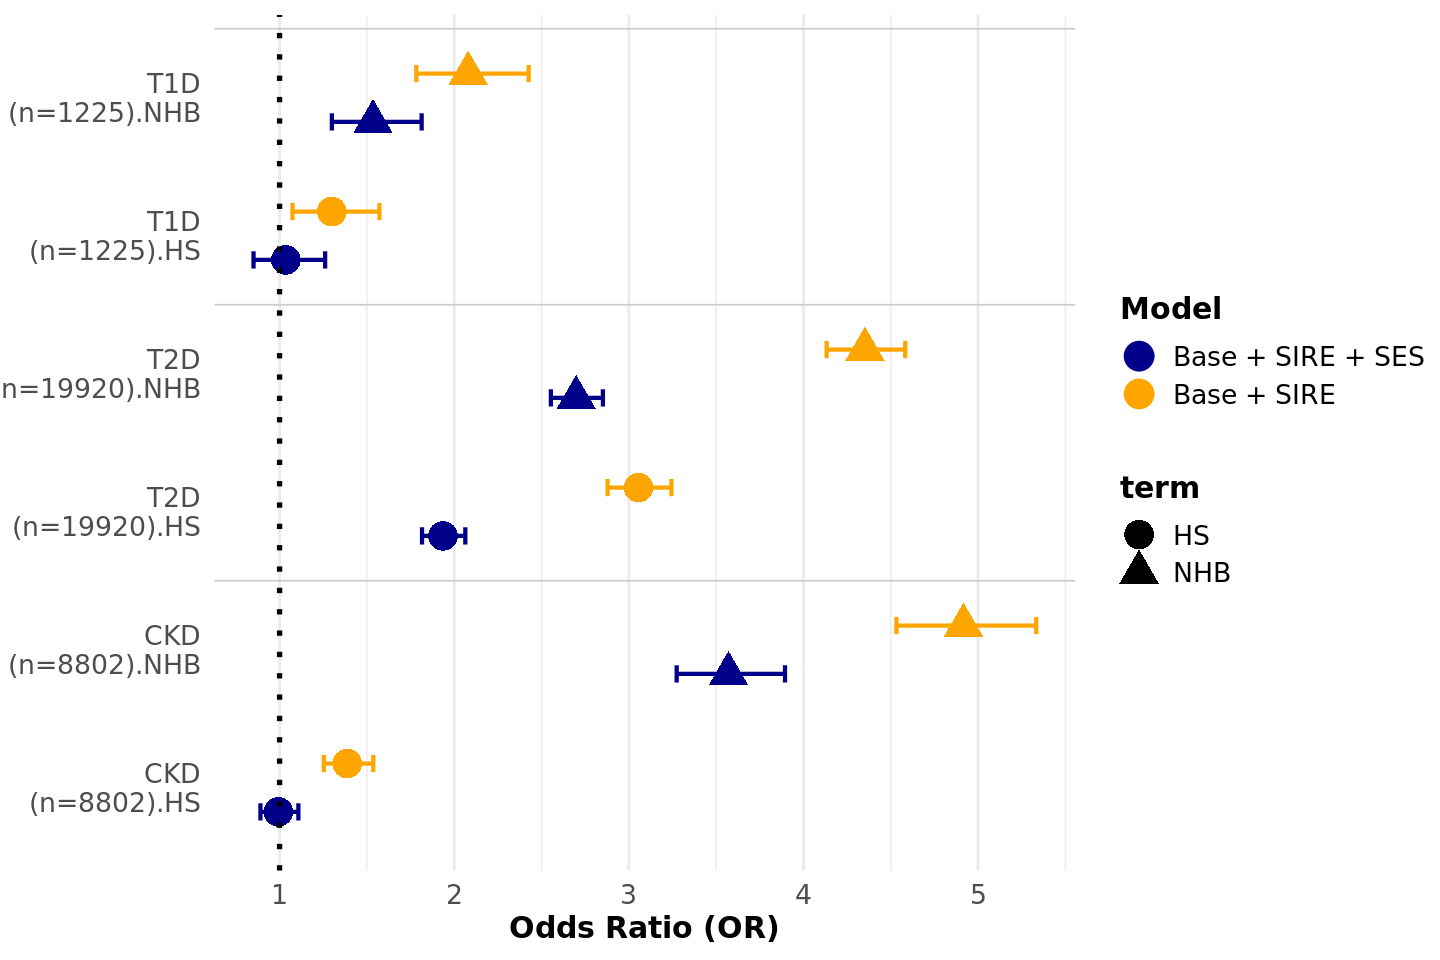

In [86]:
options(repr.plot.width = 12, repr.plot.height = 8)

results_OR_data <- results_OR_data %>%
  mutate(Disease_term = interaction(Disease, term, lex.order = TRUE))

disease_breaks <- seq(2.5,
                      length(unique(results_OR_data$Disease_term)) + 2,
                      by = length(unique(results_OR_data$term)))

ggplot(results_OR_data, 
       aes(x = OR, y = Disease_term, color = fct_rev(Model), shape = term)) +
  geom_point(position = position_dodge(width = 0.7), 
             size = 8) +   # larger points
  geom_errorbarh(aes(xmin = OR_lower, xmax = OR_upper),
                 position = position_dodge(width = 0.7), 
                 height = 0.25,
                 linewidth = 1.2) +   # thicker error bars
 scale_color_manual(values = c("Base + SIRE" = "orange",
                                "Base + SIRE + SES" = "darkblue")) +
  labs(x = "Odds Ratio (OR)", y = NULL, color = "Model") +
  theme_minimal(base_size = 18) +   # increases most text
  theme(
    legend.position = "bottom",
    strip.text = element_text(face = "bold", size = 18),
    axis.text = element_text(size = 16),
    axis.title = element_text(size = 18, face = "bold"),
    legend.text = element_text(size = 16),
    legend.title = element_text(size = 18, face = "bold")) + 
  theme(
    legend.position = "right",
    panel.grid.major.y = element_blank()) +
  geom_hline(yintercept = disease_breaks, color = "grey80") + 
  geom_vline(xintercept = 1, 
             linetype = "dotted", 
             color = "black", 
             linewidth = 1.5)

# Area Cohort

## Prepare Data

In [87]:
merged_data<-merge(zip_code_socioeconomic_df, Case_Control_df, on="person_id", how="left")

# Make one-hot encoded columns for each level of SexGender
merged_data <- merged_data %>%
  mutate(SexGender = as.factor(SexGender)) %>%
  mutate(dummy = 1) %>%
  pivot_wider(
    names_from = SexGender,
    values_from = dummy,
    values_fill = 0,
    names_prefix = ""
  )

disease_name_mapping <- c(
  "Asthma" = "Asthma\n(n=12314)",
  "Afib" = "Afib\n(n=8220)",
  "BreastC" = "Breast Cancer\n(n=5325)",
  "CKD" = "CKD\n(n=9260)",
  "CHD" = "CHD\n(n=14868)", 
  "HyperC" = "HCL\n(n=26709)",
  "ProstateC" = "Prostate Cancer\n(n=3585)",
  "t2d" = "T2D\n(n=21209)",
  "t1d" = "T1D\n(n=1289)"
)

## Logistic Regressions

### Generate Models

In [88]:
generate_model <- function(disease) {
  # Start with core predictors
  base_predictors <- c("age", "age2", "record_depth", "visit_frequency")
  
  # Conditional predictors base_predictorsd on disease
  if (disease %in% c("BreastC", "ProstateC")) {
    base_predictors <- c(base_predictors, "SGM")  # Include Cis_female and SGM for Breast Cancer
  } else if (disease %in% c("t1d", "CKD")) {
    base_predictors <- c(base_predictors, "Cis_male")  
  } else {
    base_predictors <- c(base_predictors, "Cis_male", "SGM")  # Include Cis_male and Cis_female for other diseases
  }

  
   list(Base= as.formula(paste(disease, "~", paste(base_predictors, collapse = " + "))), 
        SES = as.formula(paste(disease, "~", paste(c(base_predictors, SES), collapse = " + "))), 
         Area = as.formula(paste(disease, "~", paste(c(base_predictors, area_level), collapse = " + "))), 
         Combined = as.formula(paste(disease, "~", paste(c(base_predictors, SES, area_level), collapse = " + ")))) 
} 

### Fit Models

In [89]:
results_meta_data <- purrr::map_dfr(diseases, function(d) {

  formulas <- generate_model(d)

  purrr::imap_dfr(formulas, function(f, name) {

    fit_model(f, merged_data, d, model_name = name)$meta_data

  })

})

results_actuals <- purrr::map_dfr(diseases, function(d) {

  formulas <- generate_model(d)

  purrr::imap_dfr(formulas, function(f, name) {

    fit_model(f, merged_data, d, model_name = name)$actuals

  })

})

auc_comparisons <- purrr::map_dfr(unique(results_actuals$Disease), function(d) {

  df_d <- results_actuals %>% dplyr::filter(Disease == d)

  compare_models_auc(df_d, disease_name = d)

})

auc_comparisons <- auc_comparisons %>%
  mutate(
    bonf_p = 0.05 / nrow(auc_comparisons),      # Bonferroni threshold
    p_value_bonf = p_value * nrow(auc_comparisons), # adjusted p-value
    p_value_bonf = ifelse(p_value_bonf > 1, 1, p_value_bonf), # cap at 1
    significant = p_value < bonf_p,              # TRUE/FALSE flag
    level = case_when(
      p_value_bonf < 0.05e-10 ~ "***",
      p_value_bonf < 0.05  ~ "**",
      p_value < 0.05  ~ "*",
      TRUE ~ ""
    )
  )

nrow(auc_comparisons)

auc_comparisons <- auc_comparisons %>% mutate(Disease = as.character(Disease), 
                                                    Disease = recode(Disease, 
                                                    !!!disease_name_mapping, 
                                                                     .default = Disease) )


destination_filename <- 'logistic_regression_model_comparisons_SES_cohort.csv'

write_excel_csv(auc_comparisons, destination_filename)
system(paste0("gsutil cp ./", destination_filename, " ", my_bucket, "/data/"), intern=T)


[1] 54

character(0)

## Plot

In [90]:
# Map names
auc_plot_data <- results_meta_data %>% mutate(Disease = as.character(Disease), 
                                                    Disease = recode(Disease, 
                                                    !!!disease_name_mapping, 
                                                                     .default = Disease) )

auc_plot_data <- auc_plot_data %>%
  mutate(
    Model = factor(Model, levels = c("Base", "SES", "Area", "Combined"))
  ) %>%
  filter(!is.na(Model))

adjacent_pairs <- tibble::tibble(
  Model1 = c("SES", "Area"),
  Model2 = c("Combined", "Combined")
)

# Filter auc_comparisons to only those pairs
auc_comparisons_filtered <- auc_comparisons %>%
  mutate(
    Model1 = factor(Model1, levels = c("SES", "Area")),
    Model2 = factor(Model2, levels = c("Combined"))
  ) %>%
  semi_join(adjacent_pairs, by = c("Model1", "Model2"))

# Repeat sequence
# Base sequence
base_seq <- c(.95, 1.1)

# Generate x positions per disease
x_positions <- unlist(
  lapply(0:(n_diseases-1), function(i) base_seq + i)
)
    
y_positions <- c(.78, .76, 
                     .72, .7,
                     .78, .76, 
                     .84, .82,
                     .92, .9, 
                     .88, .86, 
                     .79, .77, 
                     .72, .7, 
                     .82, .8
                    ) 
    
    
model_colors <- c(
  "Base"    = "grey",
  "SIRE"    = "green", 
  "SES" = "skyblue",
  "Area"   = "orange",
   "Combined" = "purple"
)


# Assign in mutate
bracket_data <- auc_comparisons_filtered %>%
  mutate(
    Model1 = factor(Model1, levels = c("Base", "SES", "Area")),
    Model2 = factor(Model2, levels = c("SES", "Area", "Combined")),
  ) %>%
  # sort by Disease so brackets are in order
  arrange(Disease, Model1, Model2) %>%
  mutate(
    xstart = x_positions,
    xend   = c(1.25, 1.25, 2.25, 2.25, 3.25, 3.25, 4.25, 4.25, 5.25, 5.25, 
               6.25, 6.25, 7.25, 7.25, 8.25, 8.25, 9.25, 9.25),
    ypos   = y_positions
  ) %>%
  select(Disease, xstart, xend, ypos, Model1, Model2, p_value, Delta_AUC, level)
    

bracket_data <- bracket_data %>%
  mutate(line_group = case_when(
    Model1 == "Area" ~ "orange",
    Model1 == "SES"  ~ "lightblue",
    TRUE ~ "Other"
  ))

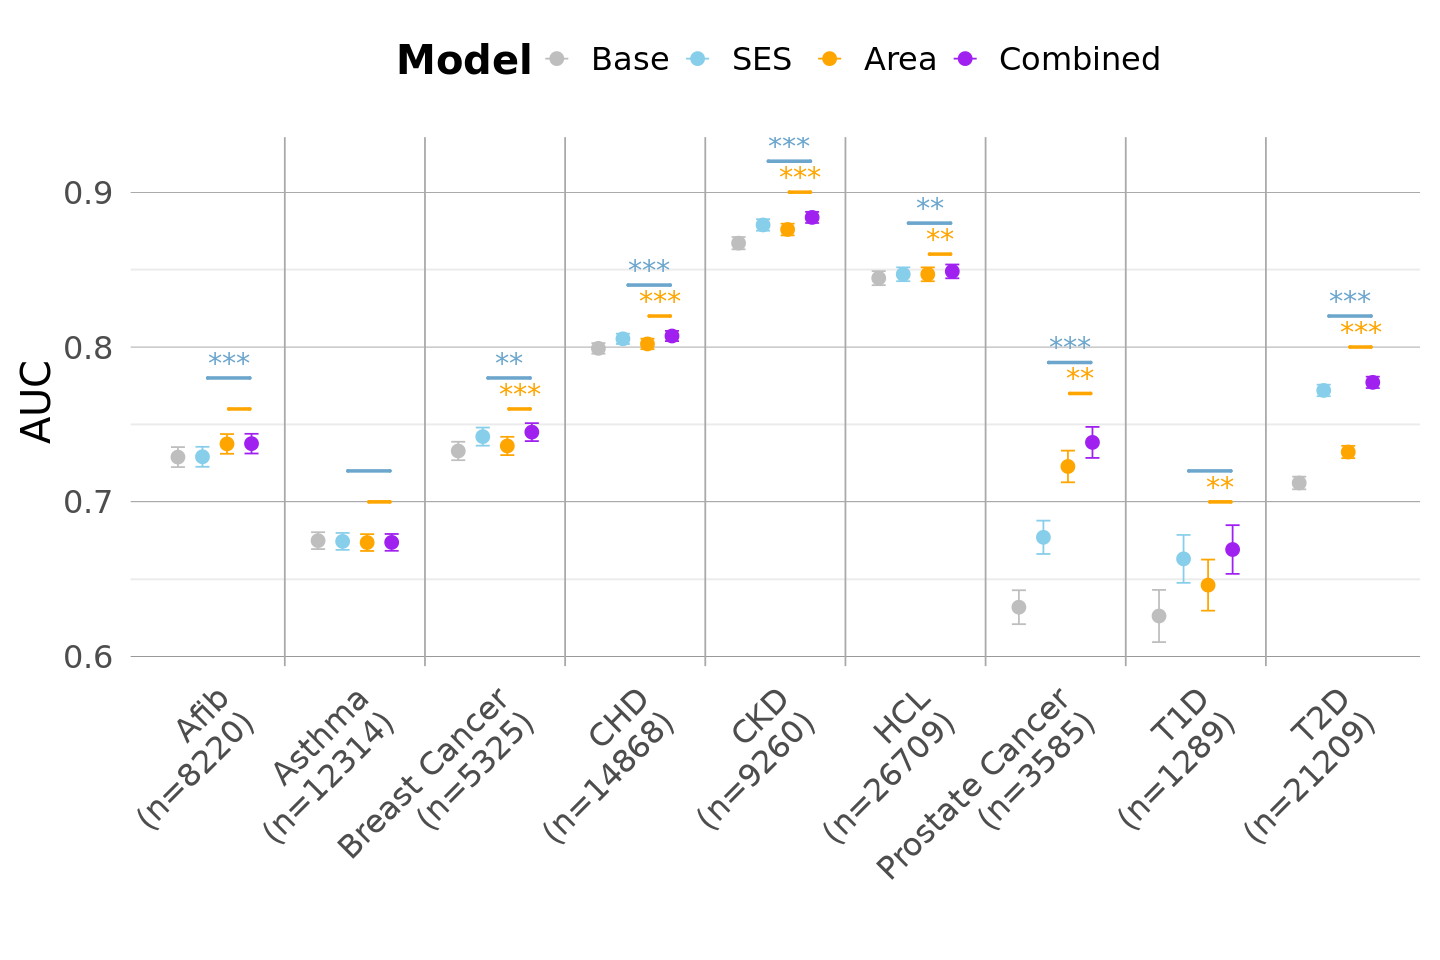

In [91]:
ggplot(auc_plot_data, aes(x = Disease, y = AUC, color = Model)) +
  geom_point(position = position_dodge(width = 0.7), size = 3.5) +
  geom_errorbar(aes(ymin = AUC_CI_Lower, ymax = AUC_CI_Upper),
                position = position_dodge(width = 0.7), width = 0.4) +
  labs(x = "", y = "AUC") +
  theme_minimal(base_size = 24) +
  theme(
    legend.position = "top",
    axis.text.x = element_text(angle = 45, hjust = 1),
    strip.text = element_text(size = 12, face = "bold"),
    legend.title = element_text(face = "bold", hjust=.5),
    panel.grid.major.x = element_blank(),
    panel.grid.major.y = element_line(size = 0.1, color = "black")
  ) +
  scale_color_manual(values = model_colors, name = "Model") +
  geom_vline(xintercept = seq(1.5,
                              length(unique(auc_plot_data$Disease)) - 0.5,
                              1), color = "darkgrey") +
    ggnewscale::new_scale_color() +

  # add comparisons
  geom_bracket(
    data = bracket_data,
    aes(xmin = xstart, 
        xmax = xend, 
        y.position = ypos,
        label = level,
       color = line_group),
    inherit.aes = FALSE,
    tip.length = 0.0,
    size = 1,
    label.size = 6
  ) +
  scale_color_manual(values = c(
    orange = "orange",
    lightblue = "skyblue3",
    Other = "black"
  ), guide = "none")
